#**Predicción de Cancelación (Churn)**

#🎯**Misión**

 Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

#🧠 **Objetivos del Desafío**

1.Preparar los datos para el modelado (tratamiento, codificación, normalización).

2.Realizar análisis de correlación y selección de variables.

3.Entrenar dos o más modelos de clasificación.

4.Evaluar el rendimiento de los modelos con métricas.

5.Interpretar los resultados, incluyendo la importancia de las variables.

6.Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

##🛠️ **Preparación de los Datos**

**Extracción del Archivo Tratado**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer





In [2]:
datos=pd.read_csv('/content/datos_tratados.csv')
datos.head(3)

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85


In [3]:
datos.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [4]:

datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [5]:
datos.describe()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,2.158675,64.761692,2279.734304
std,24.559481,1.003088,30.090047,2266.794470
min,0.000000,0.610000,18.250000,0.000000
25%,9.000000,1.180000,35.500000,398.550000
50%,29.000000,2.340000,70.350000,1394.550000
75%,55.000000,2.990000,89.850000,3786.600000
max,72.000000,3.960000,118.750000,8684.800000


**Verificación de los valores nulos**

In [6]:
datos.isnull().sum()

,0
CustomerID,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


**Eliminación de columnas**

Eliminemos columnas que no aportan valor al analisis o a los modelos predictivos, como identificadores unicos ( por ejemplo el ID del cliente). Estas columnas nos ayudan en la predicion de la cancelación y puede incluso perjudicar el desempeño de los modelos

In [7]:
if 'CustomerID' in datos.columns:
    datos = datos.drop(columns='CustomerID')

datos.head(3)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85


In [8]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    datos[col] = datos[col].replace({'No internet service': 'No'})

**Verificación de los datos nulos**

In [9]:
datos.isnull().sum()


,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## **Realizar análisis de correlación y selección de variables**

Visualiza la matriz de correlación para identificar relaciones entre varias variables numéricas. Prestando una mayor atencion a las variables que muetrean una mayor corelación con la caqncelación, ya que estasn pueden ser fuerte candidatos para el modelos predfictivo

**Selección de variables numéricas**

In [10]:
datos_numeric = datos.select_dtypes(include=['int64','float64'])

**Transformación de los datos Chunr a datos Numéricos para la corellación**

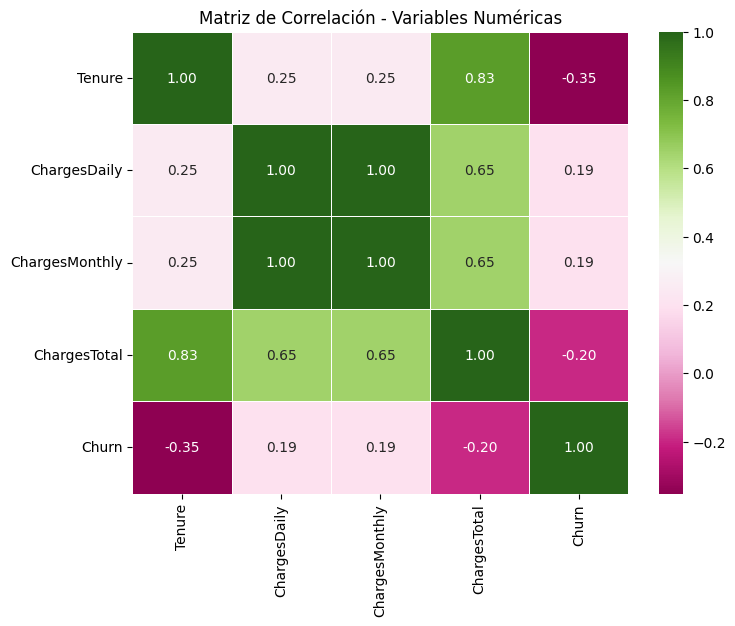

<Figure size 640x480 with 0 Axes>

In [11]:
datos_numeric['Churn']=datos['Churn'].map({"Yes": 1, "No": 0})

matriz_corr = datos_numeric.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="PiYG",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlación - Variables Numéricas")

plt.show()


plt.savefig("Matriz de Correlación - Variables Numéricas.png", dpi=300, bbox_inches='tight')
plt.show()

##**Análisis de correlación entre variables numéricas**


**Relación entre variables numéricas y Churn**

**Tenure vs Churn → -0.35**

Se observa una correlación negativa moderada entre el tiempo de permanencia del cliente (Tenure) y la cancelación del servicio.

Esto indica que a mayor antigüedad del cliente en la empresa, menor es la probabilidad de que cancele el servicio. Este resultado es coherente con el comportamiento esperado, ya que los clientes que han permanecido más tiempo suelen presentar mayor fidelización.

Por lo tanto, Tenure se perfila como una de las variables predictoras más relevantes para el modelo de predicción de churn.

**ChargesTotal vs Churn → -0.20**

Se identifica una correlación negativa débil entre el gasto total acumulado y la cancelación del servicio.

Esto sugiere que los clientes que han generado mayor facturación histórica tienden, en promedio, a cancelar menos. Sin embargo, la magnitud de la correlación es relativamente baja, lo que indica que su capacidad explicativa individual es limitada.

**ChargesDaily y ChargesMonthly vs Churn → 0.19**

Estas variables presentan una correlación positiva débil con la variable Churn. Esto implica que los clientes con cargos mensuales más elevados muestran una ligera tendencia a cancelar con mayor frecuencia.

Aunque la relación no es fuerte, estas variables podrían aportar valor predictivo cuando se combinan con otras características dentro del modelo.

Análisis de multicolinealidad entre variables predictoras

Durante el análisis también se identificaron altas correlaciones entre algunas variables explicativas, lo cual puede generar problemas de multicolinealidad en ciertos modelos de machine learning.

**ChargesDaily vs ChargesMonthly → 1.00**

Se observa una correlación perfecta, lo que indica que ambas variables contienen exactamente la misma información.

La presencia de variables altamente correlacionadas puede afectar negativamente modelos como:

##**Regresión Logística**

**Support Vector Machines (SVM)**

Debido a esta redundancia, se recomienda conservar únicamente una de estas variables en el conjunto final de entrenamiento.

**Tenure vs ChargesTotal → 0.83**

Existe una correlación positiva alta entre el tiempo de permanencia del cliente y el gasto total acumulado. Esta relación es esperable, ya que el gasto total depende directamente del tiempo que el cliente ha permanecido en el servicio.

Si bien esta correlación no representa necesariamente un problema crítico, es importante considerarla durante el proceso de selección de variables, ya que ambas podrían aportar información parcialmente redundante.

##**Conclusiones del análisis**

A partir del análisis de correlación se pueden destacar los siguientes hallazgos:

Tenure aparece como la variable con mayor relación con la cancelación del servicio, sugiriendo que la probabilidad de churn es mayor durante las primeras etapas de la relación con el cliente.

Los cargos mensuales elevados muestran una leve asociación con un mayor riesgo de cancelación.

Existen relaciones fuertes entre algunas variables predictoras, lo que requiere una adecuada selección de características para evitar problemas de multicolinealidad.

En conjunto, este análisis permite identificar variables potencialmente relevantes para el modelo predictivo y optimizar el conjunto de características a utilizar en las etapas posteriores de modelado.



##**Selección de las variable de la correlación**

**Eliminación de las columnas**

In [12]:

cols_to_drop = ['ChargesDaily', 'ChargesTotal']
existing_cols_to_drop = [col for col in cols_to_drop if col in datos.columns]

if existing_cols_to_drop:
    datos = datos.drop(columns=existing_cols_to_drop)
else:
    print(f"Columns {cols_to_drop} not found or already dropped.")

datos.head(3)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9


##**Analisis de Churn por categorias (variables categoricas)**

 **Seleción de variables categoricas**

In [13]:
categorical_cols = datos.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")


**Tabla de proporción por categoria**

In [14]:
for col in categorical_cols:
    print(f"\n✅  Analisis de variable: {col}")
    display(pd.crosstab(datos[col], datos["Churn"], normalize="index") * 100)


✅  Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



✅  Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



✅  Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



✅  Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



✅  Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


**Análisis Dirigido**

"ChargesTotal" como  fue eliminado anteriormete, se descarto su análisis . por lo tanto vamos a utilizar :

**Tiempo de contrato × Cancelación**

/tmp/ipykernel_158/930685947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


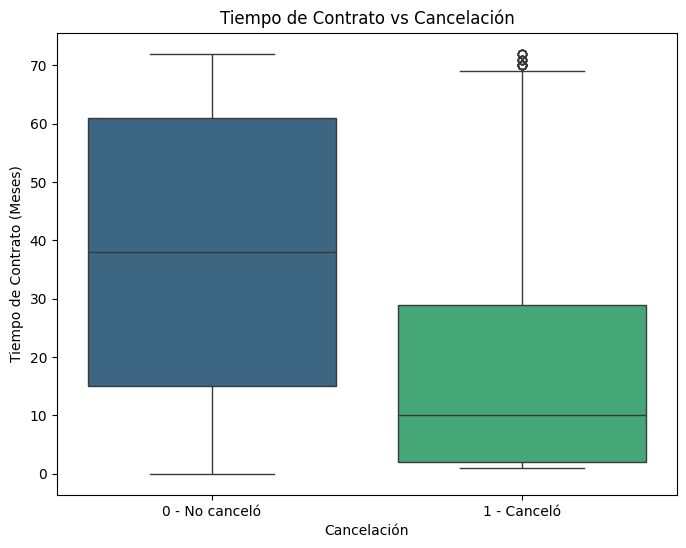

In [15]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Churn",
    y="Tenure",
    data=datos,
    palette="viridis"
)

plt.title("Tiempo de Contrato vs Cancelación")
plt.xlabel("Cancelación")
plt.xticks([0, 1], ['0 - No canceló', '1 - Canceló'])
plt.ylabel("Tiempo de Contrato (Meses)")
plt.show()

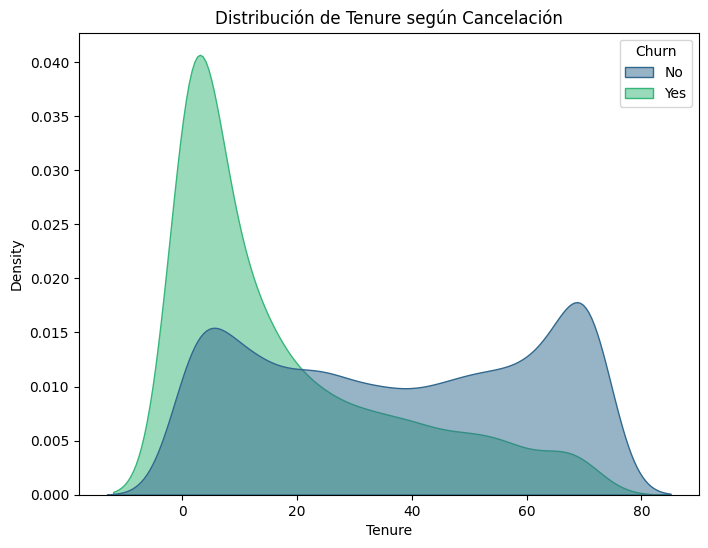

In [16]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=datos,
    x="Tenure",
    hue="Churn",
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette="viridis"

)

plt.title("Distribución de Tenure según Cancelación")
plt.show()

##🤖 **Modelado Predictivo**

**1.Separación de datos**


Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.



In [17]:
Variable_X = datos.drop('Churn', axis=1)
Variable_y = datos['Churn']

Variable_X

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60
1,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90
2,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90
3,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00
4,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15
7039,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10
7040,Male,No,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30
7041,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85


In [18]:
Variable_y

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7038,No
7039,Yes
7040,No
7041,No


In [19]:
# Separación en conjuntos de entrenamientos y Prueba

X_train, X_test, y_train, y_test = train_test_split(
    Variable_X,
    Variable_y,
    test_size=0.3,
    random_state=42,
    stratify=Variable_y
)


#Transformación de las variables expectativas

col_categoricas = X_train.select_dtypes(include='object').columns
col_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

#Creación del procesador
preprocesador = ColumnTransformer (
    transformers =[
        ('num', MinMaxScaler(), col_numericas),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), col_categoricas)
    ]
)

In [20]:
from sklearn.preprocessing import LabelEncoder


In [21]:
#Transformación de la variable respuesta

label_encoder = LabelEncoder()

In [22]:
y_train = label_encoder.fit_transform(y_train)

y_train

array([0, 1, 1, ..., 0, 0, 0])

In [23]:
y_test = label_encoder.fit_transform(y_test)

y_test



array([1, 0, 1, ..., 0, 0, 0])

In [24]:
label_encoder.classes_

array(['No', 'Yes'], dtype=object)

### **Verificación de la Proporción de Cancelaación (Churn)**

In [25]:
datos['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [26]:
datos['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [27]:
(datos['Churn'].value_counts(normalize=True) * 100).round(2)

,proportion
Churn,
No,73.46
Yes,26.54


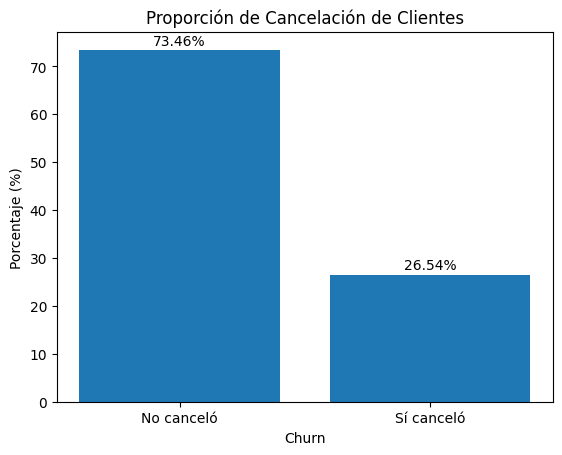

In [28]:
# Calcular proporciones en porcentaje
proporciones = (datos['Churn'].value_counts(normalize=True) * 100).round(2)

# Crear gráfica
plt.figure()
plt.bar(proporciones.index.astype(str), proporciones.values)

# Etiquetas
plt.xlabel("Churn")
plt.ylabel("Porcentaje (%)")
plt.title("Proporción de Cancelación de Clientes")
plt.xticks([0, 1], ['No canceló', 'Sí canceló'])

# Mostrar valores encima de las barras
for i, v in enumerate(proporciones.values):
    plt.text(i, v + 1, str(v) + "%", ha='center')

plt.show()

**Interpretación**

El análisis de la variable Churn muestra un desbalance moderado entre las clases. Aproximadamente 73.46% de los clientes permanecen activos, mientras que 26.54% han cancelado el servicio.

Si bien la diferencia no es extrema, este desbalance puede influir en el desempeño de los modelos predictivos, ya que algunos algoritmos tienden a favorecer la clase mayoritaria. Por este motivo, será importante considerar este aspecto durante las etapas de entrenamiento y evaluación del modelo.


**conclusión**

a variable objetivo presenta un desbalance moderado, con 73.4% de clientes activos y 26.53% de clientes que cancelaron. Este desbalance puede afectar el rendimiento del modelo, ya que la accuracy por sí sola puede ser engañosa. Por esta razón, también se evaluará el modelo utilizando precision, recall y F1-score.

In [29]:
#Vericaciones de las variables transformadas
X_train_transformado = preprocesador.fit_transform(X_train)

feature_names = preprocesador.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_transformado, columns=feature_names)

X_train_df.head()

,num__Tenure,num__ChargesMonthly,cat__Gender_Male,cat__SeniorCitizen_Yes,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,...,cat__StreamingTV_Yes,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,0.194444,0.578475,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.069444,0.514200,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.486111,0.566019,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.805556,0.674639,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.027778,0.310912,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [30]:
# Verificar normalización de numericas

X_train_df.filter(like='num__').describe()

,num__Tenure,num__ChargesMonthly
count,4930.000000,4930.000000
mean,0.451755,0.465478
std,0.341598,0.300319
min,0.000000,0.000000
25%,0.125000,0.178376
50%,0.402778,0.519930
75%,0.777778,0.714001
max,1.000000,1.000000


In [31]:
X_train_df.filter(like='cat__').head()

,cat__Gender_Male,cat__SeniorCitizen_Yes,cat__Partner_Yes,cat__Dependents_Yes,cat__PhoneService_Yes,cat__MultipleLines_Yes,cat__InternetService_DSL,cat__InternetService_Fiber optic,cat__InternetService_No,cat__OnlineSecurity_Yes,...,cat__StreamingTV_Yes,cat__StreamingMovies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__PaperlessBilling_Yes,cat__PaymentMethod_Bank transfer (automatic),cat__PaymentMethod_Credit card (automatic),cat__PaymentMethod_Electronic check,cat__PaymentMethod_Mailed check
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


**2.Creación de Modelos**


Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

**1. REGRESIÓN LOGÍSTICA**

In [32]:
from sklearn.pipeline import Pipeline


pipeline_log = Pipeline(steps=[
    ('preprocessing', preprocesador),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline_log.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  Index(['Tenure', 'ChargesMonthly'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

**2.RANDOM FOREST**

In [33]:
from sklearn.ensemble import RandomForestClassifier

Pipeline_rf = Pipeline(steps=[
    ('preprocessing', preprocesador),
    ('model', RandomForestClassifier(
        n_estimators=200,

        random_state=42
    ))
])

Pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  Index(['Tenure', 'ChargesMonthly'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

**3.Evaluación de modelos.**

valúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score


In [35]:

# Logistic
y_pred_log = pipeline_log.predict(X_test)
y_proba_log = pipeline_log.predict_proba(X_test)[:,1]


print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

=== Logistic Regression ===
Accuracy: 0.7974443918599148

Matriz de Confusión:
[[1381  171]
 [ 257  304]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113

ROC-AUC: 0.8387722356984031


In [36]:
# Random Forest
y_pred_rf = Pipeline_rf.predict(X_test)
y_proba_rf = Pipeline_rf.predict_proba(X_test)[:,1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

=== Random Forest ===
Accuracy: 0.7870326549929011

Matriz de Confusión:
[[1375  177]
 [ 273  288]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1552
           1       0.62      0.51      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113

ROC-AUC: 0.8159059898561112


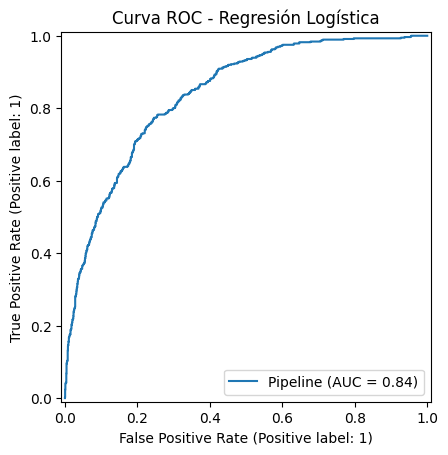

In [37]:
from sklearn.metrics import RocCurveDisplay
import os

# Create the directory if it doesn't exist
output_dir = "visualizaciones"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

RocCurveDisplay.from_estimator(pipeline_log, X_test, y_test)
plt.title("Curva ROC - Regresión Logística")
plt.savefig(os.path.join(output_dir, "roc_curve.png"), dpi=300, bbox_inches='tight')
plt.show()

In [38]:
print('Logistic Train Accuracy:', pipeline_log.score(X_train, y_train))
print('Logistic Test Accuracy:', pipeline_log.score(X_test, y_test))

print('RF Train Accuracy:', Pipeline_rf.score(X_train, y_train))
print('RF Test Accuracy:', Pipeline_rf.score(X_test, y_test))

Logistic Train Accuracy: 0.8089249492900609
Logistic Test Accuracy: 0.7974443918599148
RF Train Accuracy: 0.9975659229208925
RF Test Accuracy: 0.7870326549929011


##**Comparación de Modelos**

Se compararon los modelos Regresión Logística y Random Forest para la predicción de cancelación de clientes (churn). Ambos modelos obtuvieron un accuracy cercano al 80%, superando el desempeño de un modelo trivial basado en la clase mayoritaria (73%).

En cuanto al recall de la clase positiva, la Regresión Logística alcanzó 0.54, mientras que Random Forest obtuvo 0.51, lo que indica una mejor capacidad de la Regresión Logística para detectar clientes que cancelan. Además, la métrica ROC-AUC también favorece a este modelo (0.84 vs 0.82), evidenciando una mayor capacidad discriminativa.

Respecto a la generalización, la Regresión Logística mostró una diferencia mínima entre entrenamiento y prueba, indicando un modelo estable sin evidencia de sobreajuste. En contraste, Random Forest presentó un marcado overfitting, con una gran diferencia entre el desempeño en entrenamiento y en datos de prueba.

##**En conclusión**
Aunque el modelo Random Forest mostró una alta exactitud en el conjunto de entrenamiento (99.7%), su desempeño disminuyó notablemente en el conjunto de prueba, evidenciando sobreajuste. Por otro lado, la Regresión Logística presentó una diferencia mínima entre entrenamiento y prueba, indicando una buena capacidad de generalización. Además, obtuvo mejor desempeño en métricas clave como ROC-AUC y recall para la clase de interés (clientes que cancelan). Por lo tanto, la Regresión Logística se considera el modelo más adecuado en esta etapa inicial del análisis.

##**📋 Interpretación y Conclusiones**

###**Analisis de la importancia de las varibles**

In [39]:
#Obtener nombres de variables
feature_names = preprocesador.get_feature_names_out()

#Obteción de los coeficientes
coeficientes = pipeline_log.named_steps['model'].coef_[0]

#Creación del DataFrame ordenado
importancias = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coeficientes
})

importancias = importancias.sort_values(by='Coeficiente', ascending=False)

importancias.head(10)

,Variable,Coeficiente
9,cat__InternetService_Fiber optic,0.659272
17,cat__Contract_Month-to-month,0.561165
20,cat__PaperlessBilling_Yes,0.404922
7,cat__MultipleLines_Yes,0.280160
15,cat__StreamingTV_Yes,0.243505
1,num__ChargesMonthly,0.230291
16,cat__StreamingMovies_Yes,0.199321
23,cat__PaymentMethod_Electronic check,0.191797
3,cat__SeniorCitizen_Yes,0.172695
13,cat__DeviceProtection_Yes,0.012984


In [40]:
importancias['Abs'] = importancias['Coeficiente'].abs()
importancias.sort_values(by='Abs', ascending=False).head(15)

,Variable,Coeficiente,Abs
0,num__Tenure,-2.420735,2.420735
10,cat__InternetService_No,-0.884975,0.884975
19,cat__Contract_Two year,-0.742901,0.742901
9,cat__InternetService_Fiber optic,0.659272,0.659272
17,cat__Contract_Month-to-month,0.561165,0.561165
6,cat__PhoneService_Yes,-0.514342,0.514342
20,cat__PaperlessBilling_Yes,0.404922,0.404922
14,cat__TechSupport_Yes,-0.393020,0.393020
11,cat__OnlineSecurity_Yes,-0.284382,0.284382
7,cat__MultipleLines_Yes,0.280160,0.280160


####**Variables que más Aumentan la probabilidad de Cancelación**


*   InternetService_Fiber optic :	**0.659**
*   Contract_Month-to-month     :**0.561**








**Intepretaciones**


* **Fiber optic (+0.659)**: Los clientes con fibra óptica presentan
mayor probabilidad de cancelar, posiblemente por el mayor costo del servicio y expectativas más altas de calidad.

* **Contrato mensual (+0.561)**: Los clientes con contrato mes a mes tienen mayor tendencia a cancelar, ya que no tienen un compromiso de permanencia.

* **Cargos mensuales altos (+0.230)**: A mayor valor de MonthlyCharges, mayor probabilidad de churn, lo que indica sensibilidad al precio.

* **Pago con Electronic Check (+0.192)**: Este método de pago se asocia con mayor probabilidad de cancelación, posiblemente relacionado con menor fidelidad del cliente.

####**Variables que MÁS Reducen la Probabilidad de Cancelación**

*   Tenure	: **-2.42**




**Interpretación**

* **Tenure (-2.42)**: Es la variable más importante del modelo. A mayor antigüedad del cliente, menor probabilidad de cancelación. Esto indica que la retención en los primeros meses es clave.

* **Contrato de dos años (-0.743**): Los contratos a largo plazo reducen significativamente la probabilidad de churn, ya que implican mayor compromiso del cliente.

* **TechSupport (-0.393)**: Los clientes con soporte técnico tienden a cancelar menos, posiblemente porque pueden resolver problemas antes de frustrarse.

* **OnlineSecurity (-0.284)**: Los servicios adicionales que aportan valor aumentan la fidelidad del cliente.

#### **Conlusión**

El análisis de la Regresión Logística muestra que la antigüedad del cliente (tenure) es uno de los factores más importantes para reducir la cancelación: cuanto más tiempo lleva un cliente, menos probable es que abandone el servicio.

También se observa que los contratos de mayor duración ayudan a disminuir el churn, mientras que los contratos mensuales presentan mayor riesgo de cancelación. Por otro lado, los cargos mensuales altos y el uso de fibra óptica se asocian con una mayor probabilidad de baja.

Finalmente, contar con servicios adicionales como soporte técnico o seguridad en línea reduce la probabilidad de cancelación, lo que indica que el valor del servicio y la atención al cliente influyen en la permanencia de los usuarios.
